In [2]:
!pip install torchmetrics optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 24.2 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
import numpy as np


In [4]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    ])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='data',train=True,download=True,transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root='data',train=False,download=True,transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.2MB/s]


In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [6]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding="same"), # [32, 64, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 128, 7, 7]
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 256, 3, 3]
    nn.Flatten(), # [32, 2304]
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [8]:
from custom_utils import train, plot_history

n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(
	model,
	optimizer,
	criterion,
	metric,
	train_loader,
	valid_loader,
	n_epochs,
	warmup_scheduler=None,
	scheduler=None,
	patience=None,
	checkpoint_path='fashion_mnist_model.pt',
	clip_grad_norm=None,
  device=device
)

Epoch: 1/20, Train Loss: 0.82, Train Metric: 0.686, Valid Metric: 0.846, Time: 25.76s
	Checkpoint, valid metric : 0.846
Epoch: 2/20, Train Loss: 0.459, Train Metric: 0.839, Valid Metric: 0.861, Time: 22.65s
	Checkpoint, valid metric : 0.861
Epoch: 3/20, Train Loss: 0.397, Train Metric: 0.864, Valid Metric: 0.885, Time: 23.13s
	Checkpoint, valid metric : 0.885
Epoch: 4/20, Train Loss: 0.351, Train Metric: 0.88, Valid Metric: 0.896, Time: 22.58s
	Checkpoint, valid metric : 0.896
Epoch: 5/20, Train Loss: 0.324, Train Metric: 0.891, Valid Metric: 0.903, Time: 22.97s
	Checkpoint, valid metric : 0.903
Epoch: 6/20, Train Loss: 0.302, Train Metric: 0.898, Valid Metric: 0.908, Time: 23.09s
	Checkpoint, valid metric : 0.908
Epoch: 7/20, Train Loss: 0.284, Train Metric: 0.905, Valid Metric: 0.906, Time: 23.02s
Epoch: 8/20, Train Loss: 0.266, Train Metric: 0.91, Valid Metric: 0.883, Time: 22.09s
Epoch: 9/20, Train Loss: 0.256, Train Metric: 0.912, Valid Metric: 0.912, Time: 22.96s
	Checkpoint, val

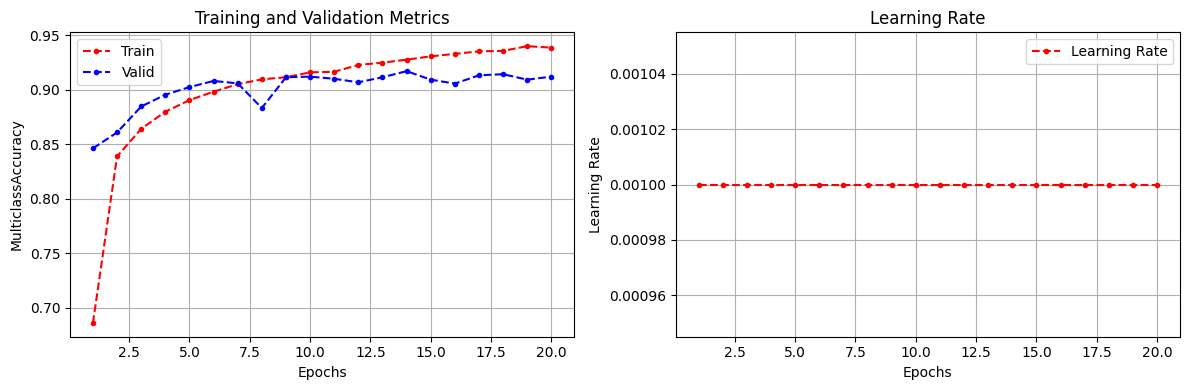

In [9]:
plot_history(history, metric)